# **Evaluación de la clasificación del LLM_Sucide_Risk**

Este notebook evalúa el rendimiento del modelo de clasificación comparando las etiquetas generadas por el LLM con las asignadas manualmente por las expertas.

El objetivo es cuantificar el grado de coincidencia entre ambas clasificaciones e identificar los principales tipos de error cometidos por el modelo.

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_excel = pd.read_excel('/content/drive/MyDrive/TFM/positivo_control/Escritorio_remoto/suicidio_positivo_control/clasificaciones_para_revision.xlsx')

In [3]:
aciertos = 0
for i, row in df_excel.iterrows():
  if row['clasif_modelo'] == row['clasif_experto']:
    aciertos += 1
  else:
    continue

accuracy = (aciertos/len(df_excel)*100)
print(f"Accuracy modelo: {accuracy:.2f}%")

Accuracy modelo: 68.56%


In [ ]:
aciertos

277

- **Predicción del modelo**

In [ ]:
df_excel.clasif_modelo.value_counts()

,count
clasif_modelo,
Dudoso,332
Positivo,72


- **Clasificación de las expertas**

In [ ]:
df_excel.clasif_experto.value_counts()

,count
clasif_experto,
Dudoso,265
Positivo,73
Control,66


## **Matriz de confusión**

In [ ]:
matriz = pd.crosstab(
    df_excel['clasif_modelo'],
    df_excel['clasif_experto'],
    rownames=['Modelo'],
    colnames=['Experto']
)

print(matriz)

Experto   Control  Dudoso  Positivo
Modelo                             
Dudoso         66     235        31
Positivo        0      30        42


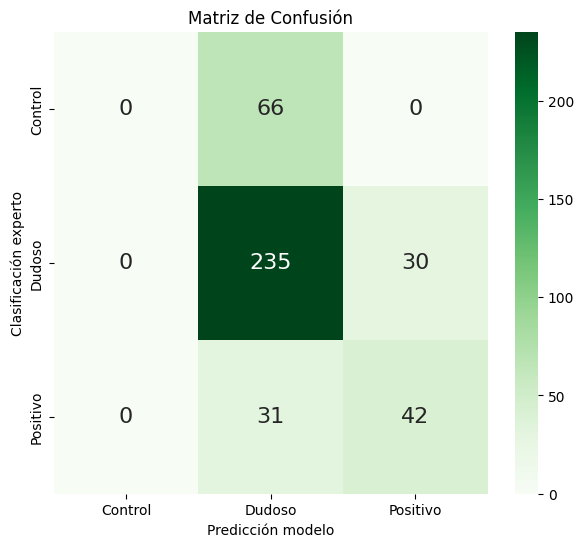

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = ['Control', 'Dudoso', 'Positivo']

conf_matrix = confusion_matrix(
    df_excel['clasif_experto'],   # y_true
    df_excel['clasif_modelo'],    # y_pred
    labels=labels
)

plt.figure(figsize=(7,6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size":16}
)

plt.xlabel('Predicción modelo')
plt.ylabel('Clasificación experto')
plt.title('Matriz de Confusión')

plt.show()

## **Análisis de errores**

In [ ]:
errores = df_excel[
    df_excel['clasif_modelo'] != df_excel['clasif_experto']
]

errores_resumen = (
    errores
    .groupby(['clasif_modelo', 'clasif_experto'])
    .size()
    .reset_index(name='count')
)

errores_resumen['% sobre errores'] = (
    errores_resumen['count']
    / errores_resumen['count'].sum()
    * 100
)

print(errores_resumen)

  clasif_modelo clasif_experto  count  % sobre errores
0        Dudoso        Control     66        51.968504
1        Dudoso       Positivo     31        24.409449
2      Positivo         Dudoso     30        23.622047
